# 🐼 Pandas Basics — Exploring the Apple Store Dataset

**Pandas** is Python's most popular data library. It lets you load, explore, clean, and analyse data using a structure called a **DataFrame** — basically a table with rows and columns, just like a spreadsheet or a SQL table.

By the end of this notebook you'll know how to:
- Load CSV files into a DataFrame
- Explore and understand your data
- Select rows and columns
- Filter, sort, and rename
- Create new calculated columns
- Summarise data with `groupby`
- Merge / join multiple DataFrames
- Spot and handle missing values
- Make quick plots

We'll use the same Apple Store dataset from the SQL notebook — `products.csv`, `customers.csv`, and `sales.csv`.

## Lesson 1 — Loading Data

`pd.read_csv()` reads a CSV file and turns it into a **DataFrame**.  
A DataFrame is like a smart spreadsheet — rows are records, columns are fields.

In [2]:
import pandas as pd

# Load all three tables
products  = pd.read_csv("products.csv")
customers = pd.read_csv("customers.csv")
sales     = pd.read_csv("sales.csv", parse_dates=["sale_date"])  # parse_dates makes the date column a proper date type

print("Data loaded!")

Data loaded!


## Lesson 2 — First Look at Your Data

These are the first things you do with ANY new dataset:

In [3]:
# .head() shows the first 5 rows (the "head" of the table)
products.head()

,product_id,category,model,storage,color,variant_detail,price_usd
0,SKU-1000,iPhone,iPhone 17,128GB,Black,Standard,999
1,SKU-1001,iPhone,iPhone 17,128GB,Black,eSIM-only,999
2,SKU-1002,iPhone,iPhone 17,128GB,Silver,Standard,999
3,SKU-1003,iPhone,iPhone 17,128GB,Silver,eSIM-only,999
4,SKU-1004,iPhone,iPhone 17,128GB,Blue,Standard,999


In [4]:
# .tail() shows the LAST 5 rows — useful to check the data doesn't cut off weirdly
sales.tail()

,sale_id,sale_date,product_id,customer_id,quantity,unit_price,total_price,store,channel
4995,4996,2025-02-04,SKU-1004,136,1,999,999,Chicago Michigan Ave,Online
4996,4997,2024-12-05,SKU-1233,283,1,649,649,Online,Online
4997,4998,2024-11-02,SKU-1220,74,1,799,799,Chicago Michigan Ave,Online
4998,4999,2025-08-23,SKU-1236,67,1,799,799,Online,Online
4999,5000,2025-10-31,SKU-1001,313,1,999,999,Dallas NorthPark,Online


In [5]:
# .shape tells you (rows, columns) — like asking "how big is this table?"
print(f"products  → {products.shape[0]:,} rows, {products.shape[1]} columns")
print(f"customers → {customers.shape[0]:,} rows, {customers.shape[1]} columns")
print(f"sales     → {sales.shape[0]:,} rows, {sales.shape[1]} columns")

products  → 361 rows, 7 columns
customers → 500 rows, 7 columns
sales     → 5,000 rows, 9 columns


In [6]:
# .info() is the most informative first-look command
# It shows: column names, data types, and how many non-null (non-empty) values there are
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   product_id      361 non-null    str  
 1   category        361 non-null    str  
 2   model           361 non-null    str  
 3   storage         325 non-null    str  
 4   color           361 non-null    str  
 5   variant_detail  361 non-null    str  
 6   price_usd       361 non-null    int64
dtypes: int64(1), str(6)
memory usage: 19.9 KB


In [7]:
# .describe() gives you stats for every numeric column at once:
# count, mean, std (standard deviation), min, 25th/50th/75th percentile, max
sales.describe()

,sale_id,sale_date,customer_id,quantity,unit_price,total_price
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,2024-12-28 07:04:30.720000,249.311800,1.183800,1194.686000,1416.534200
min,1.000000,2024-01-01 00:00:00,1.000000,1.000000,129.000000,129.000000
25%,1250.750000,2024-06-28 00:00:00,124.000000,1.000000,749.000000,799.000000
50%,2500.500000,2024-12-26 00:00:00,250.000000,1.000000,1149.000000,1299.000000
75%,3750.250000,2025-07-01 00:00:00,375.000000,1.000000,1499.000000,1599.000000
max,5000.000000,2025-12-31 00:00:00,500.000000,3.000000,9999.000000,29997.000000
std,1443.520003,NaN,144.388804,0.456573,662.341686,1062.485394


In [8]:
# .columns lists every column name — handy when you forget exact names
print(products.columns.tolist())

['product_id', 'category', 'model', 'storage', 'color', 'variant_detail', 'price_usd']


## Lesson 3 — Selecting Columns

There are two ways to pick a column:
- `df["column_name"]` → returns a **Series** (a single column)
- `df[["col1", "col2"]]` → returns a **DataFrame** (multiple columns)

In [9]:
# Single column → Series (notice: single square brackets)
products["model"].head(10)

0    iPhone 17
1    iPhone 17
2    iPhone 17
3    iPhone 17
4    iPhone 17
5    iPhone 17
6    iPhone 17
7    iPhone 17
8    iPhone 17
9    iPhone 17
Name: model, dtype: str

In [10]:
# Multiple columns → DataFrame (notice: double square brackets [[ ]])
products[["model", "category", "price_usd"]].head(10)

,model,category,price_usd
0,iPhone 17,iPhone,999
1,iPhone 17,iPhone,999
2,iPhone 17,iPhone,999
3,iPhone 17,iPhone,999
4,iPhone 17,iPhone,999
5,iPhone 17,iPhone,999
6,iPhone 17,iPhone,999
7,iPhone 17,iPhone,999
8,iPhone 17,iPhone,999
9,iPhone 17,iPhone,999


## Lesson 4 — Selecting Rows with `.loc` and `.iloc`

- **`.iloc`** — select by **position** (like list indexing: 0, 1, 2 ...)
- **`.loc`**  — select by **label / condition**

In [11]:
# .iloc — row 0 (the very first row)
products.iloc[0]

product_id         SKU-1000
category             iPhone
model             iPhone 17
storage               128GB
color                 Black
variant_detail     Standard
price_usd               999
Name: 0, dtype: object

In [12]:
# .iloc — rows 5 to 9 (slicing works just like Python lists!)
products.iloc[5:10]

,product_id,category,model,storage,color,variant_detail,price_usd
5,SKU-1005,iPhone,iPhone 17,128GB,Blue,eSIM-only,999
6,SKU-1006,iPhone,iPhone 17,128GB,Titanium,Standard,999
7,SKU-1007,iPhone,iPhone 17,128GB,Titanium,eSIM-only,999
8,SKU-1008,iPhone,iPhone 17,128GB,Red,Standard,999
9,SKU-1009,iPhone,iPhone 17,128GB,Red,eSIM-only,999


In [13]:
# .iloc — pick specific rows AND specific columns at the same time
# Format: .iloc[rows, columns]
products.iloc[0:5, 0:4]   # first 5 rows, first 4 columns

,product_id,category,model,storage
0,SKU-1000,iPhone,iPhone 17,128GB
1,SKU-1001,iPhone,iPhone 17,128GB
2,SKU-1002,iPhone,iPhone 17,128GB
3,SKU-1003,iPhone,iPhone 17,128GB
4,SKU-1004,iPhone,iPhone 17,128GB


## Lesson 5 — Filtering Rows (Boolean Indexing)

This is one of the most used pandas skills. You write a **condition**, and pandas returns only the rows where it's `True`.

In [14]:
# Filter: only iPhones
iphones = products[products["category"] == "iPhone"]
print(f"iPhone SKUs: {len(iphones)}")
iphones.head()

iPhone SKUs: 110


,product_id,category,model,storage,color,variant_detail,price_usd
0,SKU-1000,iPhone,iPhone 17,128GB,Black,Standard,999
1,SKU-1001,iPhone,iPhone 17,128GB,Black,eSIM-only,999
2,SKU-1002,iPhone,iPhone 17,128GB,Silver,Standard,999
3,SKU-1003,iPhone,iPhone 17,128GB,Silver,eSIM-only,999
4,SKU-1004,iPhone,iPhone 17,128GB,Blue,Standard,999


In [15]:
# Filter: products over $2,000
expensive = products[products["price_usd"] > 2000]
expensive[["model", "category", "price_usd"]].sort_values("price_usd", ascending=False).head(10)

,model,category,price_usd
164,Mac Pro,Mac Desktop,9999
163,Mac Pro,Mac Desktop,6999
162,Mac Studio (M5 Ultra),Mac Desktop,5999
151,"MacBook Pro (M5 Max, 16-inch)",Mac Laptop,5299
150,"MacBook Pro (M5 Max, 16-inch)",Mac Laptop,4899
148,"MacBook Pro (M5 Max, 16-inch)",Mac Laptop,4899
149,"MacBook Pro (M5 Max, 16-inch)",Mac Laptop,4699
147,"MacBook Pro (M5 Max, 16-inch)",Mac Laptop,4499
146,"MacBook Pro (M5 Max, 16-inch)",Mac Laptop,4299
161,Mac Studio (M5 Ultra),Mac Desktop,3999


In [16]:
# Multiple conditions — use & (AND) and | (OR)
# IMPORTANT: wrap each condition in parentheses ( )

# iPhones that are Blue AND under $1,200
blue_budget_iphones = products[
    (products["category"] == "iPhone") &
    (products["color"] == "Blue") &
    (products["price_usd"] < 1200)
]
blue_budget_iphones[["model", "storage", "color", "price_usd"]]

,model,storage,color,price_usd
4,iPhone 17,128GB,Blue,999
5,iPhone 17,128GB,Blue,999
14,iPhone 17,256GB,Blue,1099
15,iPhone 17,256GB,Blue,1099
24,iPhone 17,512GB,Blue,1199
25,iPhone 17,512GB,Blue,1199
94,iPhone 17e,128GB,Blue,699
95,iPhone 17e,128GB,Blue,699
104,iPhone 17e,256GB,Blue,799
105,iPhone 17e,256GB,Blue,799


In [17]:
# .isin() — match any value from a list (like SQL's IN)
mac_products = products[products["category"].isin(["Mac Laptop", "Mac Desktop"])]
print(f"Mac product variants: {len(mac_products)}")
mac_products[["model", "category", "variant_detail", "price_usd"]].head(10)

Mac product variants: 55


,model,category,variant_detail,price_usd
110,"MacBook Air (M5, 13-inch)",Mac Laptop,8GB RAM,1099
111,"MacBook Air (M5, 13-inch)",Mac Laptop,8GB RAM,1299
112,"MacBook Air (M5, 13-inch)",Mac Laptop,8GB RAM,1499
113,"MacBook Air (M5, 13-inch)",Mac Laptop,8GB RAM,1699
114,"MacBook Air (M5, 13-inch)",Mac Laptop,16GB RAM,1299
115,"MacBook Air (M5, 13-inch)",Mac Laptop,16GB RAM,1499
116,"MacBook Air (M5, 13-inch)",Mac Laptop,16GB RAM,1699
117,"MacBook Air (M5, 13-inch)",Mac Laptop,16GB RAM,1899
118,"MacBook Air (M5, 13-inch)",Mac Laptop,32GB RAM,1499
119,"MacBook Air (M5, 13-inch)",Mac Laptop,32GB RAM,1699


In [18]:
# .str.contains() — like SQL's LIKE '%Pro%'
pro_models = products[products["model"].str.contains("Pro", case=False)]
pro_models[["model", "category", "price_usd"]].drop_duplicates("model")

,model,category,price_usd
30,iPhone 17 Pro,iPhone,1299
60,iPhone 17 Pro Max,iPhone,1499
134,"MacBook Pro (M5 Pro, 14-inch)",Mac Laptop,2399
146,"MacBook Pro (M5 Max, 16-inch)",Mac Laptop,4299
163,Mac Pro,Mac Desktop,6999
261,iPad Pro 11-inch (M4),iPad,1149
293,iPad Pro 13-inch (M4),iPad,1449
355,AirPods Pro (3rd Gen),Audio,249


## Lesson 6 — Sorting

`.sort_values()` sorts a DataFrame by one or more columns.

In [19]:
# Sort by price — most expensive first
products[["model", "category", "price_usd"]].sort_values("price_usd", ascending=False).head(10)

,model,category,price_usd
164,Mac Pro,Mac Desktop,9999
163,Mac Pro,Mac Desktop,6999
162,Mac Studio (M5 Ultra),Mac Desktop,5999
151,"MacBook Pro (M5 Max, 16-inch)",Mac Laptop,5299
148,"MacBook Pro (M5 Max, 16-inch)",Mac Laptop,4899
150,"MacBook Pro (M5 Max, 16-inch)",Mac Laptop,4899
149,"MacBook Pro (M5 Max, 16-inch)",Mac Laptop,4699
147,"MacBook Pro (M5 Max, 16-inch)",Mac Laptop,4499
146,"MacBook Pro (M5 Max, 16-inch)",Mac Laptop,4299
161,Mac Studio (M5 Ultra),Mac Desktop,3999


In [20]:
# Sort by multiple columns — category A→Z, then price highest→lowest within each category
products[["model", "category", "price_usd"]].sort_values(
    ["category", "price_usd"],
    ascending=[True, False]
).head(15)

,model,category,price_usd
350,Apple Watch Ultra 3,Apple Watch,849
351,Apple Watch Ultra 3,Apple Watch,849
352,Apple Watch Ultra 3,Apple Watch,829
349,Apple Watch Ultra 3,Apple Watch,799
330,Apple Watch Series 11,Apple Watch,649
331,Apple Watch Series 11,Apple Watch,649
338,Apple Watch Series 11,Apple Watch,649
339,Apple Watch Series 11,Apple Watch,649
332,Apple Watch Series 11,Apple Watch,629
340,Apple Watch Series 11,Apple Watch,629


## Lesson 7 — Creating New Columns

You can add calculated columns to a DataFrame just by assigning to a new column name.

In [21]:
# Add a price_gbp column (using a made-up exchange rate of 0.79)
products["price_gbp"] = (products["price_usd"] * 0.79).round(2)

products[["model", "price_usd", "price_gbp"]].head(8)

,model,price_usd,price_gbp
0,iPhone 17,999,789.21
1,iPhone 17,999,789.21
2,iPhone 17,999,789.21
3,iPhone 17,999,789.21
4,iPhone 17,999,789.21
5,iPhone 17,999,789.21
6,iPhone 17,999,789.21
7,iPhone 17,999,789.21


In [22]:
# Add a price_tier column using pd.cut() — bins values into labelled ranges
products["price_tier"] = pd.cut(
    products["price_usd"],
    bins=[0, 499, 1199, 2999, float("inf")],
    labels=["Budget", "Mid-Range", "Premium", "Ultra Premium"]
)

products[["model", "category", "price_usd", "price_tier"]].head(10)

,model,category,price_usd,price_tier
0,iPhone 17,iPhone,999,Mid-Range
1,iPhone 17,iPhone,999,Mid-Range
2,iPhone 17,iPhone,999,Mid-Range
3,iPhone 17,iPhone,999,Mid-Range
4,iPhone 17,iPhone,999,Mid-Range
5,iPhone 17,iPhone,999,Mid-Range
6,iPhone 17,iPhone,999,Mid-Range
7,iPhone 17,iPhone,999,Mid-Range
8,iPhone 17,iPhone,999,Mid-Range
9,iPhone 17,iPhone,999,Mid-Range


In [23]:
# Work with dates — extract year, month, day of week from sale_date
sales["year"]        = sales["sale_date"].dt.year
sales["month"]       = sales["sale_date"].dt.month
sales["day_of_week"] = sales["sale_date"].dt.day_name()

sales[["sale_date", "year", "month", "day_of_week", "total_price"]].head(8)

,sale_date,year,month,day_of_week,total_price
0,2024-05-07,2024,5,Tuesday,449
1,2024-12-20,2024,12,Friday,1699
2,2025-10-12,2025,10,Sunday,1449
3,2025-05-29,2025,5,Thursday,1599
4,2025-09-11,2025,9,Thursday,1299
5,2024-02-16,2024,2,Friday,1499
6,2025-03-02,2025,3,Sunday,799
7,2024-11-05,2024,11,Tuesday,699


## Lesson 8 — Summarising with `value_counts()` and `groupby()`

### `value_counts()` — count how often each unique value appears

In [24]:
# How many SKUs does each category have?
products["category"].value_counts()

category
iPad           160
iPhone         110
Mac Laptop      46
Apple Watch     28
Mac Desktop      9
Audio            8
Name: count, dtype: int64

In [25]:
# Which sales channel do customers prefer?
sales["channel"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%"

channel
Online      55.4%
In-Store    44.6%
Name: proportion, dtype: str

### `groupby()` — the pandas equivalent of SQL's GROUP BY

The pattern is always:
```python
df.groupby("column")["column_to_aggregate"].aggregation_function()
```

In [26]:
# Total revenue per store — sorted highest first
sales.groupby("store")["total_price"].sum().sort_values(ascending=False)

store
Online                        2832759
Chicago Michigan Ave           514975
Boston Boylston                499466
Dallas NorthPark               490072
Miami Dadeland                 476125
San Francisco Union Square     471183
Austin Domain                  469246
New York 5th Ave               468410
Los Angeles Grove              432507
Seattle University Village     427928
Name: total_price, dtype: int64

In [27]:
# Multiple aggregations at once with .agg()
sales.groupby("store")["total_price"].agg(
    total_revenue="sum",
    avg_order="mean",
    num_transactions="count"
).round(2).sort_values("total_revenue", ascending=False)

,total_revenue,avg_order,num_transactions
store,,,
Online,2832759,1391.34,2036
Chicago Michigan Ave,514975,1454.73,354
Boston Boylston,499466,1482.09,337
Dallas NorthPark,490072,1372.75,357
Miami Dadeland,476125,1438.44,331
San Francisco Union Square,471183,1414.96,333
Austin Domain,469246,1475.62,318
New York 5th Ave,468410,1432.45,327
Los Angeles Grove,432507,1501.76,288


In [28]:
# Group by multiple columns — revenue by year AND channel
sales.groupby(["year", "channel"])["total_price"].sum().unstack()

channel,In-Store,Online
year,,
2024,1589532,1964913
2025,1564317,1963909


## Lesson 9 — Merging DataFrames (like SQL JOIN)

`pd.merge()` combines two DataFrames on a shared column.

```python
pd.merge(left_df, right_df, on="shared_column", how="inner")
```

`how=` options:
- `"inner"` — only rows that match in both tables *(default, like SQL JOIN)*
- `"left"`  — all rows from left, matched rows from right
- `"right"` — all rows from right, matched rows from left
- `"outer"` — all rows from both tables

In [29]:
# Join sales with products to see what was sold
sales_with_product = pd.merge(sales, products, on="product_id", how="inner")

print(f"Rows after merge: {len(sales_with_product)}")
sales_with_product[["sale_date", "model", "category", "color", "quantity", "total_price"]].head(10)

Rows after merge: 5000


,sale_date,model,category,color,quantity,total_price
0,2024-05-07,Apple Watch Series 11,Apple Watch,Aluminum,1,449
1,2024-12-20,iPhone 17 Pro Max,iPhone,Black,1,1699
2,2025-10-12,iPad Pro 13-inch (M4),iPad,Blue,1,1449
3,2025-05-29,iPhone 17 Pro Max,iPhone,Blue,1,1599
4,2025-09-11,iPhone 17 Pro,iPhone,Red,1,1299
5,2024-02-16,iPad Pro 11-inch (M4),iPad,Blue,1,1499
6,2025-03-02,iPad Mini,iPad,Purple,1,799
7,2024-11-05,iPad Mini,iPad,Silver,1,699
8,2025-12-06,iPhone 17e,iPhone,Black,1,799
9,2024-05-27,"MacBook Air (M5, 15-inch)",Mac Laptop,Space Grey,1,1699


In [30]:
# Chain a groupby straight onto the merged DataFrame
# — Top 10 models by total revenue
sales_with_product.groupby(["category", "model"])["total_price"].sum()\
    .reset_index()\
    .sort_values("total_price", ascending=False)\
    .rename(columns={"total_price": "total_revenue"})\
    .head(10)

,category,model,total_revenue
23,iPhone,iPhone 17 Pro Max,1054442
22,iPhone,iPhone 17 Pro,1013274
21,iPhone,iPhone 17,789083
20,iPad,iPad Pro 13-inch (M4),785833
19,iPad,iPad Pro 11-inch (M4),640436
24,iPhone,iPhone 17e,403562
17,iPad,iPad Air (M4),372809
14,Mac Laptop,"MacBook Pro (M5 Pro, 14-inch)",365280
13,Mac Laptop,"MacBook Pro (M5 Max, 16-inch)",271942
16,iPad,iPad (11th Gen),240592


In [31]:
# Now add customers too — three-table merge
full = pd.merge(sales_with_product, customers, on="customer_id", how="inner")

# Who are our top spending customers?
full.groupby(["customer_id", "first_name", "last_name", "city"])["total_price"].sum()\
    .reset_index()\
    .rename(columns={"total_price": "lifetime_spend"})\
    .sort_values("lifetime_spend", ascending=False)\
    .head(10)

,customer_id,first_name,last_name,city,lifetime_spend
433,434,Owen,Brown,New York,35733
374,375,Olivia,Robinson,Columbus,35007
380,381,Ava,Sanchez,San Francisco,34642
12,13,Lily,Jackson,Chicago,32834
61,62,Elijah,Ramirez,Charlotte,31057
370,371,Sophia,Smith,Austin,30931
324,325,Amelia,Nguyen,Jacksonville,29915
328,329,Wyatt,Allen,Houston,29777
300,301,Sophia,Robinson,Seattle,29512
75,76,Eleanor,Hill,San Diego,29473


## Lesson 10 — Renaming & Dropping Columns

In [32]:
# Rename columns for readability
customers_clean = customers.rename(columns={
    "first_name": "First Name",
    "last_name":  "Last Name",
    "member_since": "Member Since",
})
customers_clean.head(3)

,customer_id,First Name,Last Name,age,city,state,Member Since
0,1,Sophia,Johnson,63,Boston,MA,2021-07-17
1,2,Lucas,Rodriguez,63,San Diego,CA,2020-07-28
2,3,Ellie,Wright,21,Portland,OR,2023-04-24


In [33]:
# Drop columns you don't need
# axis=1 means "drop a column" (axis=0 would drop a row)
products_simple = products.drop(columns=["price_gbp", "price_tier"])
products_simple.head(3)

,product_id,category,model,storage,color,variant_detail,price_usd
0,SKU-1000,iPhone,iPhone 17,128GB,Black,Standard,999
1,SKU-1001,iPhone,iPhone 17,128GB,Black,eSIM-only,999
2,SKU-1002,iPhone,iPhone 17,128GB,Silver,Standard,999


## Lesson 11 — Missing Values

Real data is messy — it often has gaps. Pandas represents missing values as `NaN` (Not a Number).

In [34]:
# Let's create a small example with intentional missing values to demonstrate
import numpy as np

demo = pd.DataFrame({
    "product": ["iPhone 17", "AirPods Pro", "MacBook Air", "iPad Mini", "Apple Watch"],
    "units_sold": [120, 85, None, 60, None],
    "revenue":    [119880, 21165, None, 29940, None],
    "store":      ["Online", "New York", None, "Online", "Chicago"],
})
demo

,product,units_sold,revenue,store
0,iPhone 17,120.0,119880.0,Online
1,AirPods Pro,85.0,21165.0,New York
2,MacBook Air,NaN,NaN,NaN
3,iPad Mini,60.0,29940.0,Online
4,Apple Watch,NaN,NaN,Chicago


In [35]:
# .isna() — True where the value IS missing
demo.isna()

,product,units_sold,revenue,store
0,False,False,False,False
1,False,False,False,False
2,False,True,True,True
3,False,False,False,False
4,False,True,True,False


In [36]:
# Count missing values per column
demo.isna().sum()

product       0
units_sold    2
revenue       2
store         1
dtype: int64

In [37]:
# Option 1: fillna() — fill gaps with a default value
demo_filled = demo.fillna({"units_sold": 0, "revenue": 0, "store": "Unknown"})
demo_filled

,product,units_sold,revenue,store
0,iPhone 17,120.0,119880.0,Online
1,AirPods Pro,85.0,21165.0,New York
2,MacBook Air,0.0,0.0,Unknown
3,iPad Mini,60.0,29940.0,Online
4,Apple Watch,0.0,0.0,Chicago


In [38]:
# Option 2: dropna() — remove rows that have ANY missing value
demo_dropped = demo.dropna()
demo_dropped

,product,units_sold,revenue,store
0,iPhone 17,120.0,119880.0,Online
1,AirPods Pro,85.0,21165.0,New York
3,iPad Mini,60.0,29940.0,Online


## Lesson 12 — Quick Plots with pandas

pandas has `.plot()` built in — it's great for quick exploratory charts.  
*(We use `matplotlib` under the hood — no need to import it separately for basic plots.)*

Matplotlib is building the font cache; this may take a moment.


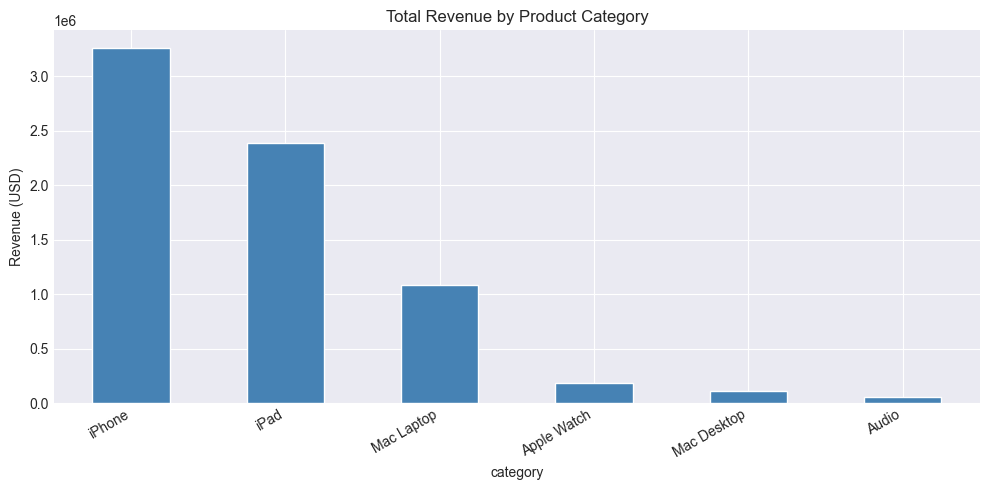

In [39]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-darkgrid")   # nicer looking charts

# Bar chart — total revenue by product category
category_revenue = sales_with_product.groupby("category")["total_price"].sum().sort_values(ascending=False)

category_revenue.plot(
    kind="bar",
    figsize=(10, 5),
    title="Total Revenue by Product Category",
    ylabel="Revenue (USD)",
    color="steelblue",
    edgecolor="white",
)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

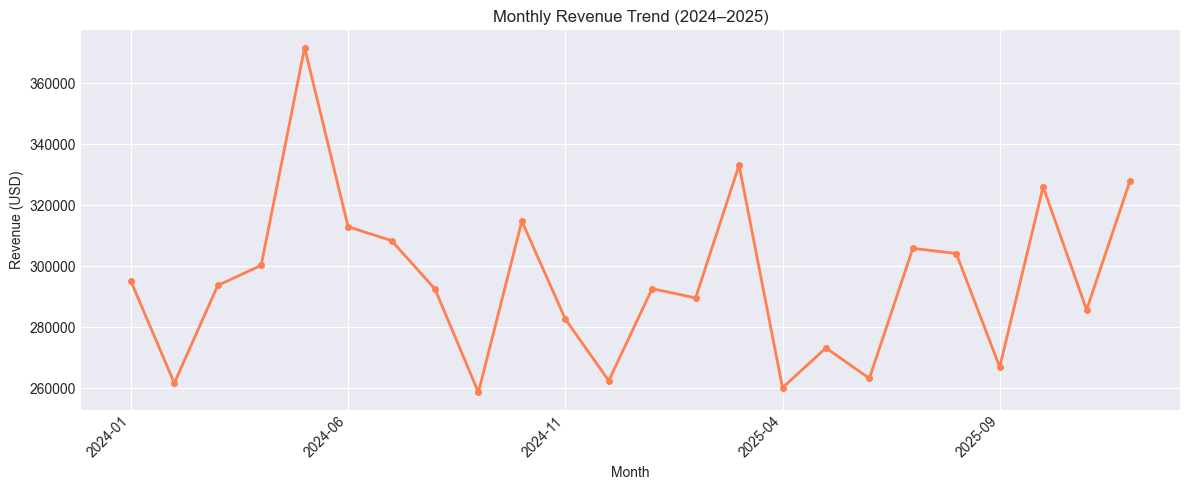

In [40]:
# Line chart — monthly revenue trend
monthly = sales.groupby(sales["sale_date"].dt.to_period("M"))["total_price"].sum()
monthly.index = monthly.index.astype(str)   # convert period to string for plotting

monthly.plot(
    kind="line",
    figsize=(12, 5),
    title="Monthly Revenue Trend (2024–2025)",
    ylabel="Revenue (USD)",
    xlabel="Month",
    color="coral",
    linewidth=2,
    marker="o",
    markersize=4,
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

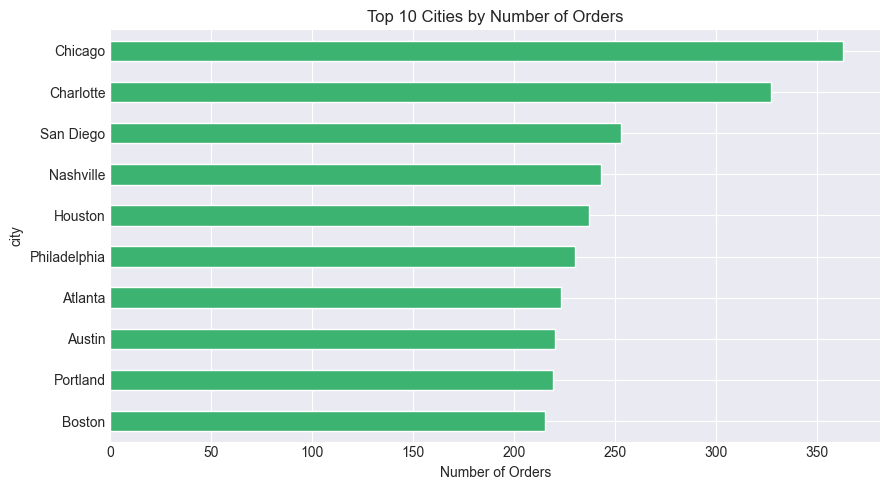

In [41]:
# Horizontal bar chart — top 10 cities by number of orders
top_cities = full.groupby("city")["sale_id"].count().sort_values(ascending=True).tail(10)

top_cities.plot(
    kind="barh",
    figsize=(9, 5),
    title="Top 10 Cities by Number of Orders",
    xlabel="Number of Orders",
    color="mediumseagreen",
    edgecolor="white",
)
plt.tight_layout()
plt.show()

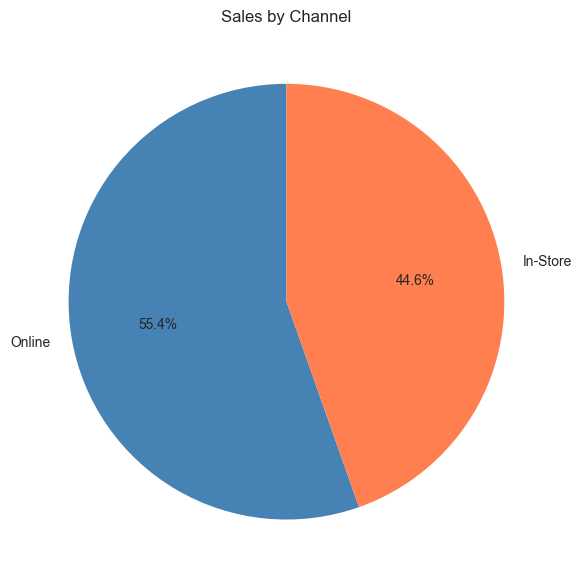

In [42]:
# Pie chart — share of sales by channel
sales["channel"].value_counts().plot(
    kind="pie",
    figsize=(6, 6),
    title="Sales by Channel",
    autopct="%1.1f%%",
    colors=["steelblue", "coral"],
    startangle=90,
)
plt.ylabel("")   # hide the default y-label
plt.tight_layout()
plt.show()

---

## 🏋️ Challenges — Try These Yourself!

### Challenge 1
> **Filter the `sales` DataFrame to only include sales from 2025, then find the top 5 stores by total revenue for that year.**

*Hint: filter using `sales["year"] == 2025`, then `groupby` + `sum` + `sort_values`*

In [54]:
# ✍️ Your code here:
sales[sales["year"] == 2025].groupby("store")['total_price'].sum().sort_values()

store
Los Angeles Grove              193082
Seattle University Village     197832
San Francisco Union Square     207901
Miami Dadeland                 242440
New York 5th Ave               246289
Chicago Michigan Ave           254850
Boston Boylston                256002
Austin Domain                  261248
Dallas NorthPark               265676
Online                        1402906
Name: total_price, dtype: int64

<details>
<summary>👀 Click to reveal the answer</summary>

```python
sales_2025 = sales[sales["year"] == 2025]
sales_2025.groupby("store")["total_price"].sum().sort_values(ascending=False).head(5)
```
</details>

---

### Challenge 2
> **Using the `full` merged DataFrame, find the average age of customers who bought each product category.**

*Hint: `groupby("category")["age"].mean()` — then round to 1 decimal place*

In [55]:
customers.head(1)

,customer_id,first_name,last_name,age,city,state,member_since
0,1,Sophia,Johnson,63,Boston,MA,2021-07-17


In [56]:
sales.head(1)

,sale_id,sale_date,product_id,customer_id,quantity,unit_price,total_price,store,channel,year,month,day_of_week
0,1,2024-05-07,SKU-1326,266,1,449,449,Online,Online,2024,5,Tuesday


In [57]:
products.head(1)

,product_id,category,model,storage,color,variant_detail,price_usd,price_gbp,price_tier
0,SKU-1000,iPhone,iPhone 17,128GB,Black,Standard,999,789.21,Mid-Range


In [90]:
# ✍️ Your code here:
merged = pd.merge(customers, sales, on='customer_id')
merged = pd.merge(merged, products, on='product_id')
merged['name'] = merged.first_name + " " + merged.last_name
merged = merged.groupby('category').agg(mean_age=('age', 'mean'), customers=('customer_id', 'nunique')).round(2).sort_values('mean_age', ascending=False)
merged.head()

,mean_age,customers
category,,
iPhone,43.99,493
Mac Laptop,43.84,275
iPad,43.70,490
Mac Desktop,43.35,22
Audio,42.65,112


<details>
<summary>👀 Click to reveal the answer</summary>

```python
full.groupby("category")["age"].mean().round(1).sort_values()
```
</details>

---

### Challenge 3 — Bring it all together
> **Create a summary DataFrame called `monthly_summary` that shows, for each month (use `sale_date` period), the total revenue, number of transactions, and the best-selling product category. Then plot it as a bar chart.**

*Hint: This one needs a few steps — monthly revenue with groupby, then a separate groupby to find the top category per month using `.idxmax()` or `.mode()`*

In [96]:
full.head()

,sale_id,sale_date,product_id,customer_id,quantity,unit_price,total_price,store,channel,year,...,variant_detail,price_usd,price_gbp,price_tier,first_name,last_name,age,city,state,member_since
0,1,2024-05-07,SKU-1326,266,1,449,449,Online,Online,2024,...,41mm / Milanese Band,449,354.71,Budget,Hannah,Hall,41,Austin,TX,2023-08-23
1,2,2024-12-20,SKU-1080,486,1,1699,1699,Dallas NorthPark,In-Store,2024,...,Standard,1699,1342.21,Premium,Sophia,Rodriguez,70,San Antonio,TX,2020-05-31
2,3,2025-10-12,SKU-1299,490,1,1449,1449,Chicago Michigan Ave,Online,2025,...,WiFi,1449,1144.71,Premium,Aubrey,Rivera,60,Philadelphia,PA,2023-07-30
3,4,2025-05-29,SKU-1075,329,1,1599,1599,Online,In-Store,2025,...,eSIM-only,1599,1263.21,Premium,Wyatt,Allen,30,Houston,TX,2023-06-13
4,5,2025-09-11,SKU-1038,173,1,1299,1299,Miami Dadeland,In-Store,2025,...,Standard,1299,1026.21,Premium,Mateo,Thomas,22,Miami,FL,2023-11-28


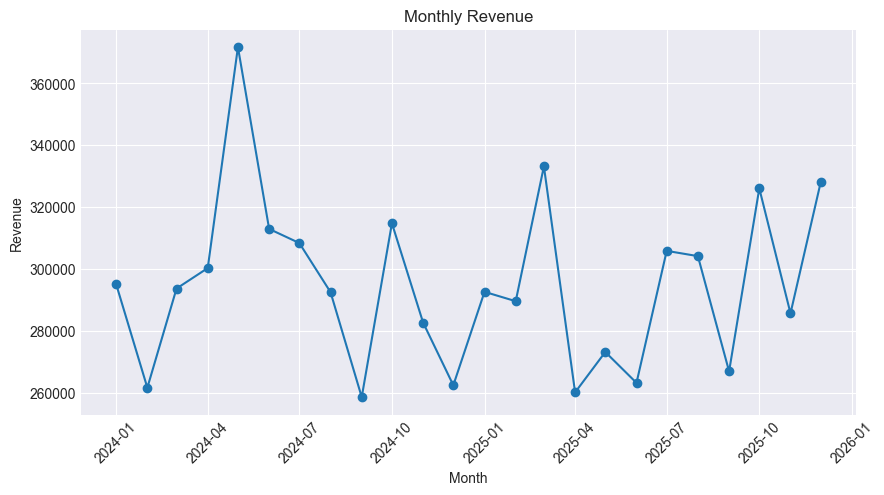

In [116]:
# ✍️ Your code here:
monthly_summary = full
monthly_summary['sale_date'] = pd.to_datetime(monthly_summary['sale_date'])
monthly_summary = monthly_summary.groupby(monthly_summary['sale_date'].dt.to_period('M')).agg(revenue=('total_price', 'sum'), transactions=('sale_id', 'count'), mode_category=('category' , lambda x: x.mode().iloc[0]))
monthly_summary.index = monthly_summary.index.to_timestamp()
monthly_summary



plt.figure(figsize=(10,5))
plt.plot(monthly_summary.index, monthly_summary['revenue'], marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

<details>
<summary>👀 Click to reveal the answer</summary>

```python
# Step 1: monthly revenue and transaction count
monthly_rev = sales_with_product.groupby(
    sales_with_product["sale_date"].dt.to_period("M")
).agg(
    total_revenue=("total_price", "sum"),
    transactions=("sale_id", "count"),
)

# Step 2: best-selling category per month
best_cat = sales_with_product.groupby(
    [sales_with_product["sale_date"].dt.to_period("M"), "category"]
)["total_price"].sum().reset_index()

best_cat = best_cat.loc[
    best_cat.groupby("sale_date")["total_price"].idxmax()
].set_index("sale_date")[["category"]].rename(columns={"category": "top_category"})

# Step 3: combine
monthly_summary = monthly_rev.join(best_cat)
print(monthly_summary.to_string())

# Step 4: plot
monthly_summary["total_revenue"].plot(
    kind="bar", figsize=(12, 5),
    title="Monthly Revenue with Transaction Count",
    color="steelblue", edgecolor="white"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
```
</details>

---

## Pandas Cheat Sheet

| Task | Code |
|------|------|
| Load CSV | `pd.read_csv("file.csv")` |
| First/last rows | `df.head()` / `df.tail()` |
| Shape | `df.shape` |
| Column types | `df.info()` |
| Stats summary | `df.describe()` |
| Select column | `df["col"]` |
| Select columns | `df[["col1", "col2"]]` |
| Filter rows | `df[df["col"] == value]` |
| Multiple filters | `df[(cond1) & (cond2)]` |
| Contains text | `df["col"].str.contains("x")` |
| In a list | `df["col"].isin([...])` |
| Sort | `df.sort_values("col", ascending=False)` |
| New column | `df["new"] = df["a"] + df["b"]` |
| Rename | `df.rename(columns={"old": "new"})` |
| Drop column | `df.drop(columns=["col"])` |
| Count per group | `df["col"].value_counts()` |
| Group & sum | `df.groupby("col")["val"].sum()` |
| Multi-agg | `.agg(name=("col", "func"))` |
| Join tables | `pd.merge(df1, df2, on="key")` |
| Missing count | `df.isna().sum()` |
| Fill missing | `df.fillna(value)` |
| Drop missing | `df.dropna()` |
| Quick plot | `df.plot(kind="bar")` |